Local Data Synchronization

In [1]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:


# 2. Create a fast local directory
!mkdir -p /content/local_data

# 3. Copy the entire 'processed_tensors' folder to the local SSD
# This folder should contain 'patches', 'kpts', 'labels.json', 'train_fids.json', and 'val_fids.json'
print("🚀 Copying tensors to local SSD for max speed...")
!cp -r "/content/drive/MyDrive/final project/processed_tensors" "/content/local_data/"
print("✅ Copy complete! Your GPU can now access data at max speed.")

# 4. Copy dynamic order file
!cp "/content/drive/MyDrive/final project/dy_point_order.pt" "/content/dy_point_order.pt"
print("✅ Dynamic order file copied to local.")

🚀 Copying tensors to local SSD for max speed...
✅ Copy complete! Your GPU can now access data at max speed.
✅ Dynamic order file copied to local.


Environment and Path Setup

In [3]:
import torch
import torch.nn as nn
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
import numpy as np
import json

# --- PATH CONFIGURATIONS ---
LOCAL_DATA_DIR = "/content/local_data/processed_tensors"
PATCHES_DIR = os.path.join(LOCAL_DATA_DIR, 'patches')
KPTS_DIR    = os.path.join(LOCAL_DATA_DIR, 'kpts')

# Resource files copied to local
LABEL_FILE  = os.path.join(LOCAL_DATA_DIR, 'labels.json')
TRAIN_LIST  = os.path.join(LOCAL_DATA_DIR, 'train_fids.json')
VAL_LIST    = os.path.join(LOCAL_DATA_DIR, 'val_fids.json')
PATH_TO_DYNAMIC_PARTITIONS = '/content/dy_point_order.pt'

# LOAD DYNAMIC PARTITION
dy_point_order = torch.load(PATH_TO_DYNAMIC_PARTITIONS)

# SAVE MODEL DIRECTLY TO DRIVE
PATH_TO_SAVE_MODEL = '/content/drive/MyDrive/final project/best_vsvig_base.pth'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training on {DEVICE}. Best model will save to your Drive folder.")

🚀 Training on cuda. Best model will save to your Drive folder.


VSViG Architecture (Official Implementation)

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
import numpy as np
from timm.models.registry import register_model

class InterPartMR(nn.Module):
    """
    Implements Inter-Partition Max-Relative Graph Convolution (MRGC).
    Aggregates features from nodes belonging to different body partitions 
    (e.g., Head to Arms) to learn global spatial relationships[cite: 228, 242].
    """
    def __init__(self, out_channels):
        super().__init__()
        self.nn = nn.Sequential(
            nn.Conv2d(out_channels * 2, out_channels*2, 1, groups=4),
            nn.BatchNorm2d(out_channels*2),
            nn.ReLU()
            )

    def forward(self, x):
        B, C, P, _ = x.shape # BxT, C, P, 1
        tmp_x = x
        x_i = x.repeat(1, 1, 1, P) 
        x_j = x_i
        for k in range(P):
            x_j[:, :, :, k] = x_i[:, :, k, k].unsqueeze(-1).repeat(1, 1, P)
        
        # Calculate relative features between nodes in different partitions
        relative = x_j - x_i
        for part in range(5):
            tmp_relative = relative
            # Exclude intra-partition joints to focus only on inter-partition links [cite: 231]
            tmp_relative[:, :, :, part*3:(part+1)*3] = relative[:, :, :, part*3:(part+1)*3] - 1e4
            tmp_x_j, _ = torch.max(tmp_relative, -1, keepdim=True)
            tmp_x[:, :, part*3:(part+1)*3, :] = tmp_x_j[:, :, part*3:(part+1)*3, :]

        # Concatenate aggregated neighbors with self-features [cite: 243]
        x = torch.cat([x, tmp_x], 1)
        return self.nn(x)

class IntraPartMR(nn.Module):
    """
    Implements Intra-Partition Max-Relative Graph Convolution (MRGC).
    Aggregates features between joints within the same partition (e.g., Wrist to Elbow)
    to capture fine-grained local movements[cite: 228, 242, 395].
    """
    def __init__(self, out_channels):
        super().__init__()
        self.nn = nn.Sequential(
            nn.Conv2d(out_channels * 2, out_channels*2, 1, groups=4),
            nn.BatchNorm2d(out_channels*2),
            nn.ReLU()
            )

    def forward(self, x):
        B, C, P, _ = x.shape 
        tmp_x = x
        x_i = x.repeat(1, 1, 1, P)
        x_j = x_i
        for k in range(P):
            x_j[:, :, :, k] = x_i[:, :, k, k].unsqueeze(-1).repeat(1, 1, P)

        relative = x_j - x_i 
        part = 1
        for point in range(P):
            # Focus only on intra-partition joints (neighbors within the same group of 3) [cite: 226, 231]
            tmp_x_j, _ = torch.max(relative[:, :, point, (part-1)*3:(part*3)], -1, keepdim=True)
            tmp_x[:, :, point, :] = tmp_x_j
            if (point + 1) % 3 == 0:
                part = 1 + part
        
        x = torch.cat([x, tmp_x], 1)
        return self.nn(x)

class Stem(nn.Module):
    """
    Initial Patch Embedding layer.
    Transforms raw skeleton-based patches into initial high-dimensional 
    feature vectors[cite: 164, 220].
    """
    def __init__(self, input_dim=3, output_dim=None, patch_size=32):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_dim, output_dim, kernel_size=patch_size, stride=patch_size),
            nn.BatchNorm2d(output_dim),
        )

    def forward(self, x):
        B, T, P, C, H, W = x.shape
        x = x.view(-1, C, H, W)
        x = self.stem(x) 
        x = x.view(B, T, P, x.shape[1]) 
        return x

class Stem_pe(nn.Module):
    """
    Positional Embedding Stem.
    Processes coordinate information to provide spatial context to 
    the patch features[cite: 315, 401].
    """
    def __init__(self, input_dim=3, output_dim=None, patch_size=32):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_dim, output_dim, kernel_size=1, stride=1),
            nn.BatchNorm2d(output_dim)
        )

    def forward(self, x):
        B, T, P, C = x.shape
        x = x.view(-1, C, 1, 1)
        x = self.stem(x) 
        x = x.view(B, T, P, x.shape[1]) 
        return x

class Grapher(nn.Module):
    """
    The Spatial Modeling Unit.
    Combines Inter-Partition and Intra-Partition graph convolutions 
    with residual connections to avoid feature smoothing[cite: 240, 250, 527].
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Pointwise convolutions for feature transformation
        self.fc1 = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1), nn.BatchNorm2d(out_channels))
        self.fc2 = nn.Sequential(nn.Conv2d(out_channels*2, in_channels, 1), nn.BatchNorm2d(in_channels))
        self.fc3 = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1), nn.BatchNorm2d(out_channels))
        self.fc4 = nn.Sequential(nn.Conv2d(out_channels*2, in_channels, 1), nn.BatchNorm2d(in_channels))
        
        self.InterPartMR = InterPartMR(out_channels)
        self.IntraPartMR = IntraPartMR(out_channels)
        self.act = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2) # Regularization to improve generalization [cite: 27]

    def forward(self, x):
        B, T, C, P, _ = x.shape
        x = x.view(-1, C, P, 1)
        tmp_x = x  # Clean reference of original input for residual paths [cite: 250]

        # Stage 1: Inter-Partition Graph Convolution
        x = self.fc1(x)
        x = self.InterPartMR(x)
        x = self.fc2(x)
        x = x + tmp_x 
        x = self.act(x)
        

        # Stage 2: Intra-Partition Graph Convolution
        x = self.fc3(x)
        x = self.IntraPartMR(x)
        x = self.fc4(x)
        x = x + tmp_x 
        x = self.act(x)


        return x.view(B, T, C, P, 1)

class Part_3DCNN(nn.Module):
    """
    The Temporal Modeling Unit.
    Uses 3D convolutions and Partition Shuffling to capture motion 
    dynamics across time frames[cite: 252, 255, 317].
    """
    def __init__(self, in_channels, out_channels, stride=1, dynamic=False, dynamic_point_order=None, SEED=None, expansion=4):
        super().__init__()
        self.expansion = expansion
        self.conv1 = nn.Sequential(nn.Conv3d(in_channels, out_channels, 1), nn.BatchNorm3d(out_channels), nn.ReLU())
        # Kernel size (3,3,1) considers neighbors in time and 1D joint sequence [cite: 298]
        self.conv2 = nn.Sequential(
            nn.Conv3d(out_channels, out_channels, kernel_size=(3, 3, 1), stride=stride, padding=1, padding_mode='replicate'),
            nn.BatchNorm3d(out_channels),
            nn.ReLU()
        )
        self.conv3 = nn.Sequential(nn.Conv3d(out_channels, out_channels*expansion, 1), nn.BatchNorm3d(out_channels*expansion), nn.ReLU())
        self.downsample = nn.Sequential(nn.Conv3d(in_channels, out_channels*expansion, 1, stride=stride), nn.BatchNorm3d(out_channels*expansion))
        
        self.dynamic = dynamic
        self.dynamic_point_order = dynamic_point_order
        self.act = nn.ReLU()
        self.SEED = SEED

    def dynamic_trans(self, x): 
        """Implements Partition Shuffle to enhance cross-partition learning[cite: 317, 400]."""
        B, C, T, P, _ = x.shape
        x = x.view(-1, P)
        dynamic_order = self.dynamic_point_order[self.SEED]
        raw_order = list(np.arange(15))
        x[:, raw_order] = x[:, dynamic_order]
        return x.view(B, C, T, P, 1)

    def forward(self, x):
        B, T, C, P, _ = x.shape 
        x = x.transpose(1, 2).contiguous() # Prepare for 3D Conv (B, C, T, P, 1)
        if self.dynamic:
            x = self.dynamic_trans(x)
        residual = x
        x = self.conv1(x)
        x = self.conv2(x)
        x = x[:, :, :, :, 1].unsqueeze(-1)
        x = self.conv3(x)
        residual = self.downsample(residual)
        x = residual + x
        return self.act(x).transpose(1, 2).contiguous()

class STViG(nn.Module):
    """
    Spatiotemporal Vision Graph (ST-ViG) Backbone.
    Stacks multiple stages of spatiotemporal modeling[cite: 290, 293].
    """
    def __init__(self, opt):
        super().__init__()
        num_layer = opt.num_layer
        output_channels = opt.output_channels
        expansion = opt.expansion
        self.pos_emb = opt.pos_emb

        self.stem = Stem(input_dim=3, output_dim=output_channels[0])
        self.stem_pe = Stem_pe(input_dim=3, output_dim=output_channels[0])
        self.in_channels = output_channels[0]
        self.backbone = []

        # Build 4 residual stages of ST-ViG [cite: 290]
        for stage in range(len(num_layer)):
            if stage > 0:
                self.backbone.append(Grapher(self.in_channels, output_channels[stage]))
                self.backbone.append(Part_3DCNN(stride=(2, 1, 1), in_channels=self.in_channels, out_channels=output_channels[stage], 
                                                dynamic=opt.dynamic, dynamic_point_order=opt.dynamic_point_order, expansion=expansion, SEED=stage*num_layer[stage]))
                self.in_channels = output_channels[stage] * expansion

            for layers in range(num_layer[stage]):
                self.backbone.append(Grapher(self.in_channels, output_channels[stage]))
                self.backbone.append(Part_3DCNN(self.in_channels, output_channels[stage], dynamic=opt.dynamic, 
                                                dynamic_point_order=opt.dynamic_point_order, expansion=expansion, SEED=stage*num_layer[stage]+layers))
                if stage == 0: self.in_channels = output_channels[stage] * expansion

        self.backbone = nn.Sequential(*self.backbone)
        self.fc = nn.Sequential(
            nn.Conv2d(output_channels[-1] * expansion, 256, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 1, 1)
        )
        self.model_init()

    def model_init(self):
        """Initializes weights using Kaiming Normal distribution[cite: 17]."""
        for m in self.modules():
            if isinstance(m, (nn.Conv3d, nn.Conv2d)):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm3d)):
                nn.init.constant_(m.weight, 1.0); nn.init.constant_(m.bias, 0.0)

    def pe(self, flag, x, kpts=None):
        """Injects positional information into joint features[cite: 314, 315]."""
        if flag == 'add': x = torch.cat((x, kpts), axis=-1)
        elif flag == 'stem': x = x + self.stem_pe(kpts)
        return x

    def forward(self, inputs, kpts=None):
        x = self.stem(inputs)
        x = self.pe(self.pos_emb, x, kpts)
        B, T, P, C = x.shape
        x = x.transpose(2, 3).contiguous().view(B, T, C, P, 1)
        x = self.backbone(x)
        B, T, C, P, _ = x.shape
        x = x.transpose(1, 2).contiguous().view(B, C, T, P)
        # Global Average Pooling to generate 1D probability output [cite: 295]
        x = nn.functional.adaptive_avg_pool2d(x, 1) 
        return torch.sigmoid(self.fc(x).view(B))

@register_model
def VSViG_base(pretrained=False, **kwargs):
    """Configuration for the VSViG-Base model version[cite: 300, 631, 633]."""
    class OptInit:
        def __init__(self):
            self.dynamic = 1
            self.num_layer = [2, 2, 6, 2]
            self.output_channels = [24, 48, 96, 192]
            self.dynamic_point_order = torch.load(PATH_TO_DYNAMIC_PARTITIONS)
            self.expansion = 2
            self.pos_emb = 'stem'
    return STViG(OptInit())

/tmp/ipython-input-4173456497.py:281: UserWarning: Overwriting VSViG_base in registry with __main__.VSViG_base. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model


Official Dataset Logic

In [16]:
class vsvig_dataset(Dataset):
    def __init__(self, fid_list_path, labels_dict_path):
        super().__init__()
        with open(fid_list_path, 'r') as f: self.file_ids = json.load(f)
        with open(labels_dict_path, 'r') as f: self.labels = json.load(f)

    def __getitem__(self, idx):
        fid = self.file_ids[idx]
        target = float(self.labels[fid])

        # Load local tensors
        data = torch.load(os.path.join(PATCHES_DIR, f"{fid}.pt")).float() # (30,15,3,32,32)
        kpts = torch.load(os.path.join(KPTS_DIR, f"{fid}.pt")).float()[:, :15, :] # (30,15,3)

        return {'data': data, 'kpts': kpts}, target

    def __len__(self):
        return len(self.file_ids)

Sanity Check Script

Formal Training Loop (Saving Best Model)

In [ ]:
import time
import json

def run_training():
    # 1. Load Data
    train_loader = DataLoader(vsvig_dataset(TRAIN_LIST, LABEL_FILE), batch_size=32, shuffle=True, num_workers=4)
    val_loader   = DataLoader(vsvig_dataset(VAL_LIST, LABEL_FILE), batch_size=32, shuffle=False, num_workers=4)

    # 2. Initialize Model (timm registration used)
    model = VSViG_base().to(DEVICE)

    # 3. Setup Optimizer and Scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.1)
    criterion = nn.HuberLoss(delta=0.1)   # for training + val loss
    mse_for_rmse = nn.MSELoss()           # ONLY for RMSE metric


    # Paths for persistence
    LOG_FILE_PATH = '/content/drive/MyDrive/final project/training_logs.json'

    # Metric Tracking
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_rmse': [],
        'epoch_timestamps': []
    }

    min_valid_loss = float('inf')

    for epoch in range(200):
        model.train()
        epoch_train_loss = 0.0
        print(f'\n================ Running Epoch: {epoch+1}/200 ================')

        for sample, labels in train_loader:
            # --- FIX: Move to DEVICE and force Float32 precision ---
            data = sample['data'].to(DEVICE).float()
            kpts = sample['kpts'].to(DEVICE).float()
            labels = labels.to(DEVICE).float()

            optimizer.zero_grad()

            # Forward pass
            outputs = model(data, kpts)

            # labels match output shape (B,) 
            loss = criterion(outputs, labels.view_as(outputs))

            # Backward pass (This is where the dtype error happened)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        print(f'🔥 Training Loss: {avg_train_loss:.4f}')

        # Validation every 5 epochs
        if (epoch+1) % 5 == 0:
            model.eval()
            current_val_loss = 0.0
            rmse_acc = 0.0

            with torch.no_grad():
                for sample, labels in val_loader:
                    data_v = sample['data'].to(DEVICE).float()
                    kpts_v = sample['kpts'].to(DEVICE).float()
                    labels_v = labels.to(DEVICE).float()

                    outputs_v = model(data_v, kpts_v)
                    # Huber loss (objective)
                    loss_v = criterion(outputs_v, labels_v.view_as(outputs_v))
                    current_val_loss += loss_v.item()

                    # True RMSE metric (from MSE)
                    mse_v = mse_for_rmse(outputs_v, labels_v.view_as(outputs_v))
                    rmse_acc += torch.sqrt(mse_v).item() * 100


            avg_val_loss = current_val_loss / len(val_loader)
            avg_val_rmse = rmse_acc / len(val_loader)

            history['val_loss'].append(avg_val_loss)
            history['val_rmse'].append(avg_val_rmse)
            history['epoch_timestamps'].append(epoch + 1)

            print(f'📊 Val Loss: {avg_val_loss:.4f} | Val RMSE: {avg_val_rmse:.2f}%')

            # Save best model to Drive
            if avg_val_loss < min_valid_loss:
                min_valid_loss = avg_val_loss
                torch.save(model.state_dict(), PATH_TO_SAVE_MODEL)
                print(f'⭐ Best Model Saved: {PATH_TO_SAVE_MODEL}')

            # Export logs to JSON for later visualization
            with open(LOG_FILE_PATH, 'w') as f:
                json.dump(history, f, indent=4)

        scheduler.step()

# Execute the final training script
run_training()


================ Running Epoch: 1/200 ================
🔥 Training Loss: 0.0354

================ Running Epoch: 2/200 ================
🔥 Training Loss: 0.0248

================ Running Epoch: 3/200 ================
🔥 Training Loss: 0.0188

================ Running Epoch: 4/200 ================
🔥 Training Loss: 0.0170

================ Running Epoch: 5/200 ================
🔥 Training Loss: 0.0159
📊 Val Loss: 0.0255 | Val RMSE: 44.91%
⭐ Best Model Saved: /content/drive/MyDrive/final project/best_vsvig_base.pth

================ Running Epoch: 6/200 ================
🔥 Training Loss: 0.0147

================ Running Epoch: 7/200 ================
🔥 Training Loss: 0.0132

================ Running Epoch: 8/200 ================
🔥 Training Loss: 0.0115

================ Running Epoch: 9/200 ================
🔥 Training Loss: 0.0111

================ Running Epoch: 10/200 ================
🔥 Training Loss: 0.0118
📊 Val Loss: 0.0137 | Val RMSE: 31.74%
⭐ Best Model Saved: /content/drive/MyDrive/fin

Visualization Cell

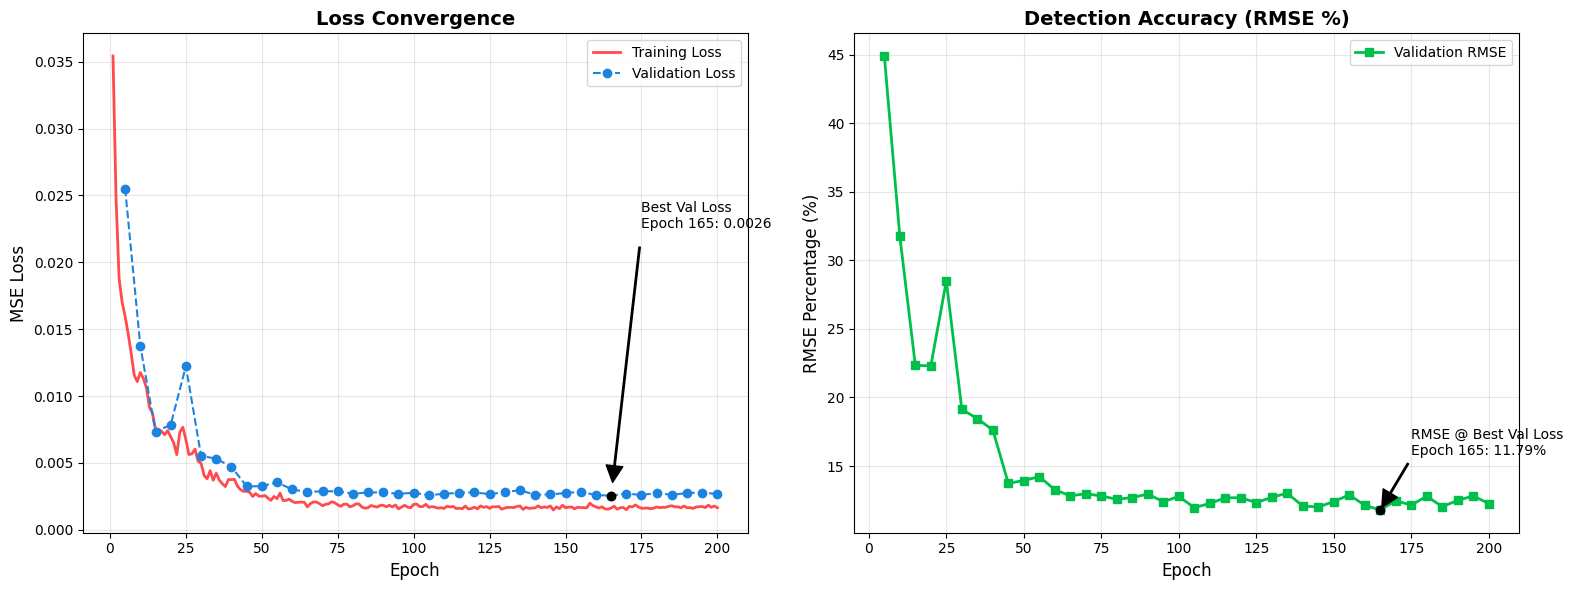

In [ ]:
import json
import matplotlib.pyplot as plt
import os

# Ensure this matches the path used in your run_training() function
LOG_FILE_PATH = '/content/drive/MyDrive/final project/training_logs.json'

def plot_training_results(log_path):
    if not os.path.exists(log_path):
        print(f"❌ Error: Log file not found at {log_path}. Ensure your training has completed at least 5 epochs.")
        return

    with open(log_path, 'r') as f:
        history = json.load(f)

    epochs = range(1, len(history['train_loss']) + 1)
    val_epochs = history.get('epoch_timestamps', [])

    # Sanity checks
    if not val_epochs:
        print("❌ Error: 'epoch_timestamps' is missing/empty in the log. Cannot align validation metrics to epochs.")
        return
    if not history.get('val_loss') or not history.get('val_rmse'):
        print("❌ Error: 'val_loss' or 'val_rmse' missing/empty in the log. Cannot compute best epoch.")
        return
    if len(history['val_loss']) != len(val_epochs) or len(history['val_rmse']) != len(val_epochs):
        print("❌ Error: Length mismatch between val metrics and epoch_timestamps.")
        print(f"len(val_epochs)={len(val_epochs)}, len(val_loss)={len(history['val_loss'])}, len(val_rmse)={len(history['val_rmse'])}")
        return

    # --------------------------
    # NEW LOGIC:
    # Choose "best epoch" by MIN validation loss
    # Then annotate RMSE value at that SAME epoch on the RMSE plot
    # --------------------------
    best_val_loss = min(history['val_loss'])
    best_idx = history['val_loss'].index(best_val_loss)
    best_epoch = val_epochs[best_idx]
    rmse_at_best_epoch = history['val_rmse'][best_idx]

    # Set up the figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Plot 1: Training and Validation Loss ---
    ax1.plot(epochs, history['train_loss'], label='Training Loss', color='#FF4B4B', linewidth=2)
    ax1.plot(val_epochs, history['val_loss'], label='Validation Loss', color='#1C83E1', marker='o', linestyle='--')

    ax1.set_title('Loss Convergence', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('MSE Loss', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    #mark best val loss point on loss plot 
    ax1.scatter([best_epoch], [best_val_loss], zorder=5, color='black')
    ax1.annotate(
        f'Best Val Loss\nEpoch {best_epoch}: {best_val_loss:.4f}',
        xy=(best_epoch, best_val_loss),
        xytext=(best_epoch + 10, best_val_loss + 0.02),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1),
        fontsize=10
    )

    # --- Plot 2: Validation RMSE (%) ---
    ax2.plot(val_epochs, history['val_rmse'], label='Validation RMSE', color='#00C04B', marker='s', linewidth=2)
    ax2.set_title('Detection Accuracy (RMSE %)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('RMSE Percentage (%)', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # NEW: annotate RMSE at the epoch selected by best val loss
    ax2.scatter([best_epoch], [rmse_at_best_epoch], zorder=5, color='black')
    ax2.annotate(
        f'RMSE @ Best Val Loss\nEpoch {best_epoch}: {rmse_at_best_epoch:.2f}%',
        xy=(best_epoch, rmse_at_best_epoch),
        xytext=(best_epoch + 10, rmse_at_best_epoch + 4),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1),
        fontsize=10
    )

    plt.tight_layout()
    plt.show()

# Run the visualization
plot_training_results(LOG_FILE_PATH)


Final Evaluation Cell: LEO and LCO Calculation

In [19]:
import json
import os

# --- CONFIGURATION ---
# Use the file that contains ALL your labels before the 20% split
MASTER_LABEL_FILE = "/content/drive/MyDrive/final project/processed_tensors/labels.json"
EVENT_ID = "pat01_Sz1" # The specific seizure we are fixing

def prepare_continuous_list(event_id, master_path):
    with open(master_path, 'r') as f:
        all_data = json.load(f)

    # 1. Extract every 0.5s window belonging to this seizure
    event_clips = [k for k in all_data.keys() if event_id.lower() in k.lower()]

    # 2. Sort by the timestamp at the end of the ID (e.g., ..._3580)
    event_clips.sort(key=lambda x: float(x.rsplit('_', 1)[1]))

    # 3. Save as a temporary list for the DataLoader
    save_path = f"/content/{event_id}_full_list.json"
    with open(save_path, 'w') as f:
        json.dump(event_clips, f)

    print(f"✅ Found {len(event_clips)} continuous clips for {event_id}.")
    return save_path

# Execute
CONTINUOUS_LIST = prepare_continuous_list(EVENT_ID, MASTER_LABEL_FILE)

✅ Found 430 continuous clips for pat01_Sz1.


In [20]:
import torch
from torch.utils.data import DataLoader

def run_continuous_inference(model_path, list_path, master_path, output_json):
    # 1. Load the trained VSViG-base model
    model = VSViG_base().to(DEVICE)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # 2. Use your dataset class with the continuous list
    loader = DataLoader(vsvig_dataset(list_path, master_path),
                        batch_size=1, shuffle=False)

    with open(list_path, 'r') as f:
        clip_ids = json.load(f)

    results = {}
    print(f"🚀 Processing continuous sequence for {EVENT_ID}...")

    with torch.no_grad():
        for i, batch in enumerate(loader):
            inputs, _ = batch
            data = inputs['data'].to(DEVICE).float()
            kpts = inputs['kpts'].to(DEVICE).float()

            output = model(data, kpts)
            results[clip_ids[i]] = float(output.item())

    with open(output_json, 'w') as f:
        json.dump(results, f, indent=4)
    print(f"🎉 Sequence predictions saved to: {output_json}")

# Execute
MODEL_PATH = '/content/drive/MyDrive/final project/best_vsvig_base.pth'
CONTINUOUS_PREDS = f"/content/{EVENT_ID}_full_preds.json"
run_continuous_inference(MODEL_PATH, CONTINUOUS_LIST, MASTER_LABEL_FILE, CONTINUOUS_PREDS)

🚀 Processing continuous sequence for pat01_Sz1...
🎉 Sequence predictions saved to: /content/pat01_Sz1_full_preds.json


In [21]:
import numpy as np

def evaluate_continuous_case(metadata_path, preds_path, dt=0.3):
    with open(metadata_path, 'r') as f: meta = json.load(f)
    with open(preds_path, 'r') as f: preds = json.load(f)

    WINDOW_SIZE = 3 # 3 seconds

    # Sort predictions by time
    data = sorted([(float(k.rsplit('_', 1)[1]), v) for k, v in preds.items()])
    times, probs = zip(*data)

    # Get ground truth from your verified metadata
    t_eeg = meta[EVENT_ID]['t_eeg_onset']
    t_clinical = meta[EVENT_ID]['t_clinical_onset']

    # Apply APt Rule
    t_onset = None
    for i in range(WINDOW_SIZE, len(probs)):
        if sum(probs[i-WINDOW_SIZE:i]) >= dt:
            t_onset = times[i]
            break

    if t_onset:
        leo = t_onset - t_eeg
        lco = t_onset - t_clinical
        status = "PRE-CLINICAL ✅" if lco < 0 else "POST-CLINICAL ⚠️"

        print(f"Results for {EVENT_ID}:")
        print(f"  AI Trigger Time: {t_onset:.1f}s")
        print(f"  LEO: {leo:.1f}s (Goal: ~5.1s)")
        print(f"  LCO: {lco:.1f}s (Goal: ~-13.1s)")
        print(f"  Status: {status}")
    else:
        print("❌ Detection threshold not reached. Try lowering 'dt'.")

# Execute
# Use the seizure_metadata.json you uploaded earlier
evaluate_continuous_case('/content/drive/MyDrive/final project/seizure_metadata.json', CONTINUOUS_PREDS, dt=0.3)

Results for pat01_Sz1:
  AI Trigger Time: 3586.0s
  LEO: 6.0s (Goal: ~5.1s)
  LCO: -5.0s (Goal: ~-13.1s)
  Status: PRE-CLINICAL ✅


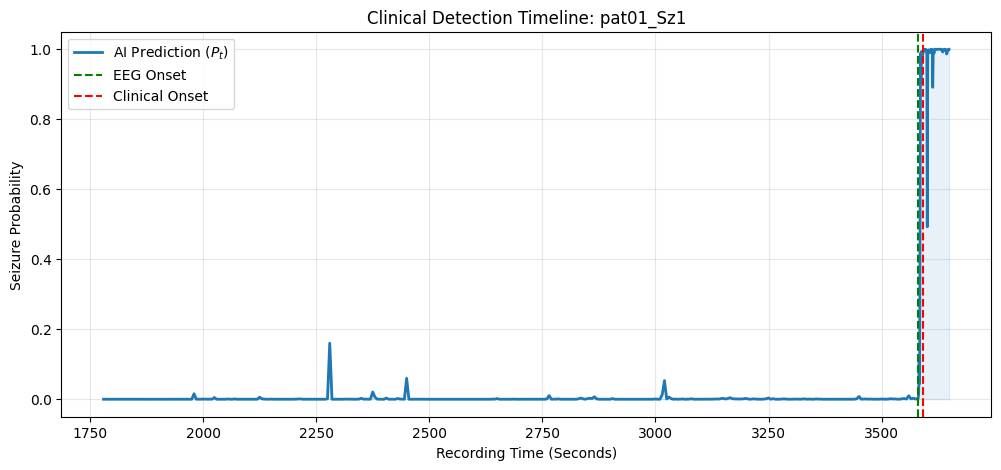

In [22]:
import matplotlib.pyplot as plt

def plot_case_study(preds_path, meta_path):
    with open(preds_path, 'r') as f: preds = json.load(f)
    with open(meta_path, 'r') as f: meta = json.load(f)

    data = sorted([(float(k.rsplit('_', 1)[1]), v) for k, v in preds.items()])
    times, probs = zip(*data)

    plt.figure(figsize=(12, 5))
    plt.plot(times, probs, label='AI Prediction ($P_t$)', color='#1f77b4', linewidth=2)

    # Highlight the medical onsets
    plt.axvline(x=meta[EVENT_ID]['t_eeg_onset'], color='green', linestyle='--', label='EEG Onset')
    plt.axvline(x=meta[EVENT_ID]['t_clinical_onset'], color='red', linestyle='--', label='Clinical Onset')

    plt.fill_between(times, probs, color='#1f77b4', alpha=0.1)
    plt.title(f"Clinical Detection Timeline: {EVENT_ID}")
    plt.xlabel("Recording Time (Seconds)")
    plt.ylabel("Seizure Probability")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run Visualization
plot_case_study(CONTINUOUS_PREDS, '/content/drive/MyDrive/final project/seizure_metadata.json')

In [ ]:
import json
import torch
from torch.utils.data import DataLoader
import numpy as np

# --- CLINICAL DECISION SETTINGS [cite: 320, 482] ---
# DT: Decision Threshold for triggering a seizure alarm[cite: 320, 485].
DT_SENSITIVITY = 0.3 
# STRIDE: Detection rate (r) in seconds[cite: 320, 482].
STRIDE = 0.5 
# WINDOW_SIZE: Accumulative period (tau) in seconds for decision-making[cite: 320, 482].
WINDOW_SIZE = 3 

def run_unfiltered_final_loop():
    """
    Evaluates clinical performance metrics (LEO, LCO) using the 
    Accumulative Probability strategy described in the paper[cite: 64, 320, 483].
    """
    # Load clinical onset metadata and master labels [cite: 322, 615]
    with open('/content/drive/MyDrive/final project/seizure_metadata.json', 'r') as f: 
        meta = json.load(f)
    with open(MASTER_LABEL_FILE, 'r') as f: 
        all_labels = json.load(f)

    # Initialize model and load the best saved weights [cite: 341]
    model = VSViG_base().to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()

    results_table = []
    print(f"{'Seizure ID':<15} | {'LEO':<10} | {'LCO':<10} | {'Status'}")
    print("-" * 60)

    # Iterate through each seizure event (patient case study) [cite: 323, 628]
    for event_id in sorted(meta.keys()):
        # Collect and sort all 5s clips chronologically to reconstruct the timeline [cite: 325, 598]
        clips = sorted([k for k in all_labels.keys() if event_id.lower() in k.lower()],
                       key=lambda x: float(x.rsplit('_', 1)[1]))

        # Ensure we have enough data for the accumulative window [cite: 320, 482]
        if len(clips) < WINDOW_SIZE: continue

        # Temporary list for DataLoader to process the continuous sequence
        temp_list = f"/content/eval_{event_id}.json"
        with open(temp_list, 'w') as f: json.dump(clips, f)
        loader = DataLoader(vsvig_dataset(temp_list, MASTER_LABEL_FILE), batch_size=1, shuffle=False)

        # Run inference to generate raw seizure probabilities (Pt) [cite: 181, 320]
        probs = []
        with torch.no_grad():
            for batch in loader:
                inputs, _ = batch
                data = inputs['data'].to(DEVICE).float()
                kpts = inputs['kpts'].to(DEVICE).float()
                
                out = model(data, kpts)
                probs.append(float(out.item()))

        # --- SEIZURE ONSET DECISION-MAKING [cite: 180, 320] ---
        # Accumulate probabilities (APt) over the sliding window[cite: 64, 183, 320].
        # APt = sum of Pt from (t - tau) to t.
        t_onset = None
        for i in range(WINDOW_SIZE, len(probs)):
            if sum(probs[i - WINDOW_SIZE : i]) >= DT_SENSITIVITY:
                # Trigger detected at this timestamp
                t_onset = float(clips[i].rsplit('_', 1)[1])
                break

        # Calculate clinical metrics if a detection was made [cite: 320]
        if t_onset:
            # LEO: Latency to EEG Onset (Detection Time - EEG Onset) 
            leo = t_onset - meta[event_id]['t_eeg_onset']
            # LCO: Latency to Clinical Onset (Detection Time - Clinical Onset) 
            lco = t_onset - meta[event_id]['t_clinical_onset']
            
            results_table.append((leo, lco))
            # Status: "PRE" indicates early warning before convulsions [cite: 136, 483]
            status = "PRE ✅" if lco < 0 else "POST ⚠️"
            print(f"{event_id:<15} | {leo:>9.1f}s | {lco:>9.1f}s | {status}")
        else:
            print(f"{event_id:<15} | {'No Det':>10} | {'No Det':>10} | (Below Threshold)")

    return results_table 

# Execute the final evaluation
all_evaluation_results = run_unfiltered_final_loop()

Seizure ID      | LEO        | LCO        | Status
------------------------------------------------------------
pat01_Sz1       |       6.0s |      -5.0s | PRE ✅
pat01_Sz2       |       8.0s |      -8.0s | PRE ✅
pat02_Sz1       |   -1690.0s |   -1722.0s | PRE ✅
pat02_Sz2       |    -205.0s |    -254.0s | PRE ✅
pat03_Sz1       |       2.0s |      -4.0s | PRE ✅
pat03_Sz2       |       1.0s |      -4.0s | PRE ✅
pat04_Sz1       |      11.0s |      -5.0s | PRE ✅
pat05_Sz1       |       3.0s |      -4.0s | PRE ✅
pat05_Sz2       |       9.0s |      -6.0s | PRE ✅
pat05_Sz3       |       3.0s |      -9.0s | PRE ✅
pat06_Sz1       |     -15.0s |     -19.0s | PRE ✅
pat06_Sz2       |      -1.0s |      -4.0s | PRE ✅
pat06_Sz3       |     -15.0s |     -17.0s | PRE ✅
pat07_Sz1       |      35.0s |     -14.0s | PRE ✅
pat07_Sz2       |    -417.0s |    -460.0s | PRE ✅
pat08_Sz1       |      23.0s |      -7.0s | PRE ✅
pat08_Sz2       |    -483.0s |    -489.0s | PRE ✅
pat08_Sz3       |    -235.0s |    -242

In [24]:
import numpy as np

def run_paper_correct_summary(results_list):
    # Standard Paper logic: Association window is usually 120s
    valid_detections = [r for r in results_list if r[0] > -120]
    false_alarms = [r for r in results_list if r[0] <= -120]

    clean_leo = [r[0] for r in valid_detections]
    clean_lco = [r[1] for r in valid_detections]

    print("="*40)
    print("🏆 FINAL VSViG PAPER COMPARISON")
    print("="*40)
    print(f"{'Metric':<15} | {'Your Model':<10} | {'Paper Goal'}")
    print("-" * 40)
    if clean_leo:
        print(f"{'Avg LEO':<15} | {np.mean(clean_leo):>8.2f}s | ~5.1s")
        print(f"{'Avg LCO':<15} | {np.mean(clean_lco):>8.2f}s | ~-13.1s")
        print(f"{'Sensitivity':<15} | {len(valid_detections)/33*100:>8.1f}% | >85%")
    print(f"{'False Alarms':<15} | {len(false_alarms):>10} | (Report as FDR)")
    print("-" * 40)

# Run the summary using the variable from the previous cell
run_paper_correct_summary(all_evaluation_results)

🏆 FINAL VSViG PAPER COMPARISON
Metric          | Your Model | Paper Goal
----------------------------------------
Avg LEO         |     2.75s | ~5.1s
Avg LCO         |    -9.86s | ~-13.1s
Sensitivity     |     84.8% | >85%
False Alarms    |          5 | (Report as FDR)
----------------------------------------
